In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("/nTraining samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.15MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.10MB/s]

Training samples: 60000
Test samples: 10000


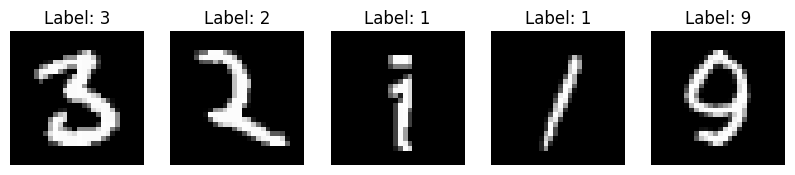

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()

In [ ]:
def add_gaussian_noise(images, mean=0.0, std=0.5):
    noise = torch.randn(images.size(), device=images.device) * std + mean
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

In [ ]:
clean_images, _ = next(iter(train_loader))

noisy_images = add_gaussian_noise(clean_images)

print("Clean shape:", clean_images.shape)
print("Noisy shape:", noisy_images.shape)

Clean shape: torch.Size([128, 1, 28, 28])
Noisy shape: torch.Size([128, 1, 28, 28])


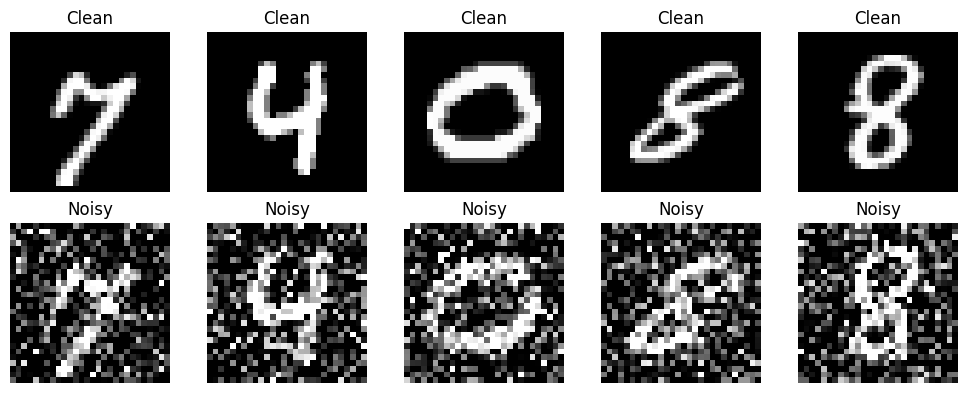

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(5):
    # Clean images
    plt.subplot(2, 5, i + 1)
    plt.imshow(clean_images[i].squeeze(), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

    # Noisy images
    plt.subplot(2, 5, i + 6)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)   # Flatten
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = decoded.view(x.size(0), 1, 28, 28)
        return decoded

In [ ]:
model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", total_params)

Total trainable parameters: 218192


In [ ]:
num_epochs = 15
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for clean_images, _ in train_loader:
        clean_images = clean_images.to(device)

        # Add Gaussian noise
        noisy_images = add_gaussian_noise(clean_images)

        # Forward pass
        outputs = model(noisy_images)
        loss = criterion(outputs, clean_images)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Epoch [1/15], Loss: 0.060789
Epoch [2/15], Loss: 0.035181
Epoch [3/15], Loss: 0.029197
Epoch [4/15], Loss: 0.026407
Epoch [5/15], Loss: 0.024311
Epoch [6/15], Loss: 0.022880
Epoch [7/15], Loss: 0.021891
Epoch [8/15], Loss: 0.021108
Epoch [9/15], Loss: 0.020445
Epoch [10/15], Loss: 0.019877
Epoch [11/15], Loss: 0.019432
Epoch [12/15], Loss: 0.019064
Epoch [13/15], Loss: 0.018759
Epoch [14/15], Loss: 0.018515
Epoch [15/15], Loss: 0.018285


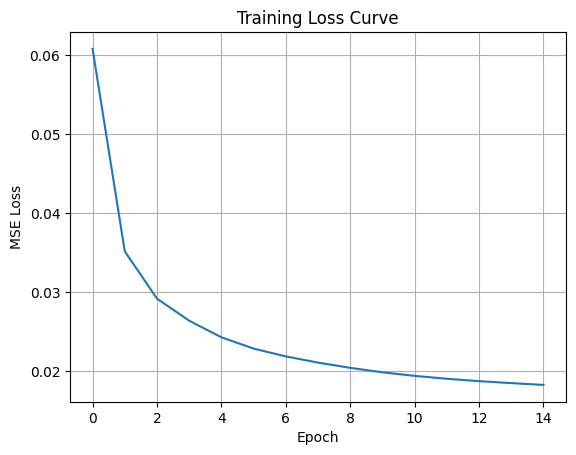

In [ ]:
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [ ]:
model.eval()

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

In [ ]:
# Get a batch of test images
clean_images, _ = next(iter(test_loader))
clean_images = clean_images.to(device)

# Add noise
noisy_images = add_gaussian_noise(clean_images)

# Reconstruct images
with torch.no_grad():
    reconstructed_images = model(noisy_images)

In [ ]:
clean_images = clean_images.cpu()
noisy_images = noisy_images.cpu()
reconstructed_images = reconstructed_images.cpu()

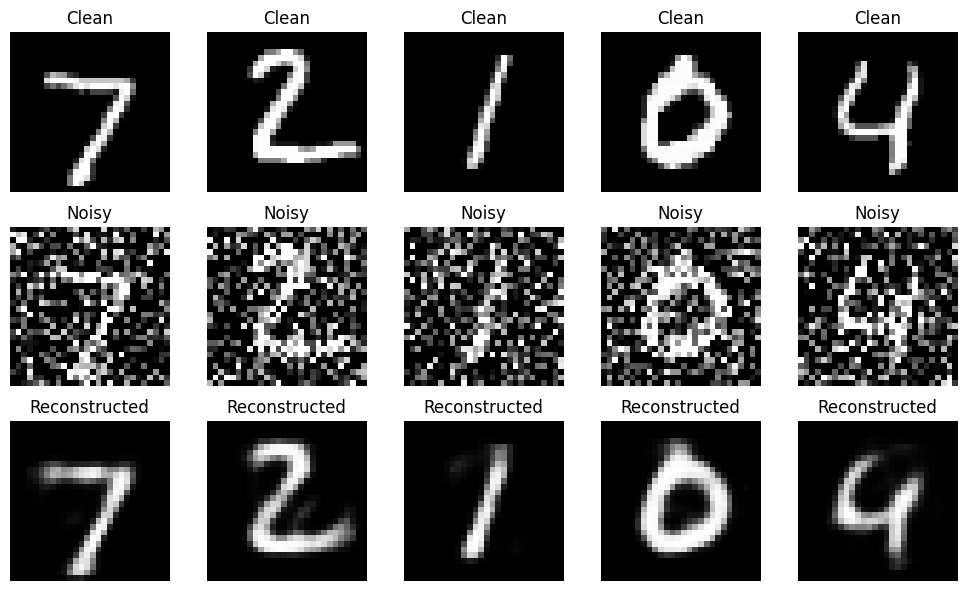

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(5):
    # Clean images
    plt.subplot(3, 5, i + 1)
    plt.imshow(clean_images[i].squeeze(), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

    # Noisy images
    plt.subplot(3, 5, i + 6)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed images
    plt.subplot(3, 5, i + 11)
    plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

## **For Final Review. CNN in 2 Pipelines and Optimal Bottleneck**

In [ ]:
# Run only if using Google Colab
!pip install torch torchvision scikit-learn matplotlib seaborn


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import pandas as pd
import os


In [ ]:
os.makedirs("reports", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)


# **CNN CLASSIFIER (USED IN BOTH PIPELINES)**

In [ ]:
class CNNClassifier(nn.Module):
    def __init__(self, input_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# **PIPELINE 1 — CNN BEFORE ENCODER**

In [ ]:
cnn_noisy = CNNClassifier().to(device)
optimizer = optim.Adam(cnn_noisy.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 15
cnn_noisy.train()

for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        noisy_images = add_gaussian_noise(images)

        outputs = cnn_noisy(noisy_images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1, Loss: 0.4665
Epoch 2, Loss: 0.1677
Epoch 3, Loss: 0.1333
Epoch 4, Loss: 0.1204
Epoch 5, Loss: 0.1044
Epoch 6, Loss: 0.0963
Epoch 7, Loss: 0.0897
Epoch 8, Loss: 0.0857
Epoch 9, Loss: 0.0815
Epoch 10, Loss: 0.0784
Epoch 11, Loss: 0.0728
Epoch 12, Loss: 0.0715
Epoch 13, Loss: 0.0691
Epoch 14, Loss: 0.0658
Epoch 15, Loss: 0.0663


In [ ]:
cnn_noisy.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = add_gaussian_noise(images).to(device)
        outputs = cnn_noisy(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())


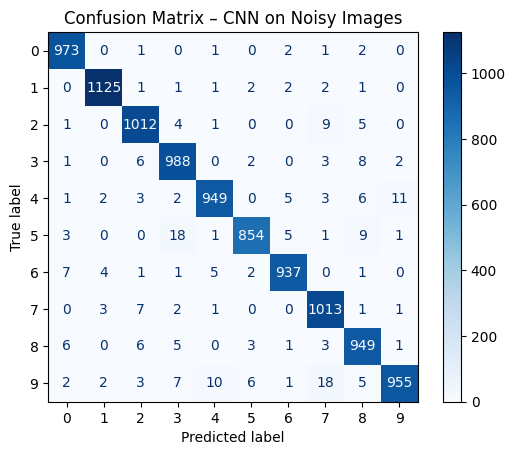

In [ ]:
cm_noisy = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm_noisy)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – CNN on Noisy Images")
plt.savefig("reports/figures/cm_noisy.png")
plt.show()


In [ ]:
params_noisy = sum(p.numel() for p in cnn_noisy.parameters() if p.requires_grad)
print("CNN Parameters (Before Encoder):", params_noisy)


CNN Parameters (Before Encoder): 421642


## **# MATRIX REPRESENTATION (ENCODER → BOTTLENECK → DECODER)**

In [ ]:
model.eval()
sample_img, _ = next(iter(test_loader))
sample_img = sample_img[0:1].to(device)
noisy_sample = add_gaussian_noise(sample_img)


In [ ]:
with torch.no_grad():
    encoded = model.encoder(noisy_sample.view(1, -1))

print("Encoder Output Shape:", encoded.shape)
print(encoded.cpu().numpy())


Encoder Output Shape: torch.Size([1, 64])
[[0.         0.         5.177597   0.5956514  4.4329476  4.0510054
  2.5200322  0.         2.623169   3.2621086  5.8282604  3.0923772
  0.         0.38371027 0.         1.052325   4.8165073  1.4069955
  0.         4.8905697  0.         9.39586    1.5280255  0.
  0.         3.853197   5.9063253  1.1718123  0.         0.
  0.4216922  1.992362   1.6097121  5.40024    0.         3.9474454
  0.         0.         0.         0.         0.         0.
  0.         3.8494372  5.3316154  0.         3.692567   0.
  0.         0.         1.8592725  5.125146   3.7594495  0.
  0.         6.03925    3.2621322  1.7163535  3.6258085  0.
  0.         3.8573775  0.         0.        ]]


In [ ]:
bottleneck = encoded
print("Bottleneck Matrix Shape:", bottleneck.shape)


Bottleneck Matrix Shape: torch.Size([1, 64])


In [ ]:
decoded = model.decoder(bottleneck).view(1, 28, 28)

print("Decoder Output Shape:", decoded.shape)
print(decoded.cpu().detach().numpy())

Decoder Output Shape: torch.Size([1, 28, 28])
[[[2.43958802e-05 3.38831560e-05 3.09521383e-05 1.39681524e-05
   1.28611500e-04 5.17808840e-05 4.69453553e-05 2.11685292e-05
   1.63923924e-05 1.04439159e-05 2.29668549e-05 1.31011320e-05
   2.27300461e-05 4.72641113e-05 4.70827326e-05 1.28697866e-04
   6.34506287e-05 5.81863023e-05 6.15161189e-05 4.32824527e-05
   2.38859629e-05 4.89588092e-05 3.02870412e-05 4.90705206e-05
   9.45102802e-05 5.73483630e-05 1.75701389e-05 1.50116284e-05]
  [5.91632397e-06 5.46794108e-05 4.94777232e-05 9.21287356e-05
   7.47619852e-05 6.40141370e-05 3.24168250e-05 7.32330518e-05
   2.52299415e-05 1.00055506e-04 2.78787866e-05 1.47832961e-05
   7.71027317e-06 3.62972278e-05 8.11030361e-07 1.15932755e-06
   3.48249232e-05 1.88338108e-05 7.68999871e-06 4.36119262e-05
   2.97874867e-05 7.99749705e-06 5.54254484e-06 2.39007495e-05
   3.53990981e-05 3.13415112e-05 4.62784337e-05 5.37565757e-05]
  [1.65272941e-05 5.72507270e-05 2.52326845e-05 2.96629241e-05
   5.37

# **PIPELINE 2 — CNN AT BOTTLENECK**

In [ ]:
def extract_bottleneck_features(autoencoder, loader):
    features, labels = [], []

    autoencoder.eval()
    with torch.no_grad():
        for images, lbls in loader:
            images = add_gaussian_noise(images).to(device)
            encoded = autoencoder.encoder(images.view(images.size(0), -1))
            features.append(encoded.cpu())
            labels.append(lbls)

    return torch.cat(features), torch.cat(labels)


In [ ]:
X_train, y_train = extract_bottleneck_features(model, train_loader)
X_test, y_test = extract_bottleneck_features(model, test_loader)


In [ ]:
class BottleneckClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.fc(x)


In [ ]:
clf_bn = BottleneckClassifier(X_train.shape[1]).to(device)
optimizer = optim.Adam(clf_bn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


In [ ]:
for epoch in range(15):
    optimizer.zero_grad()
    outputs = clf_bn(X_train.to(device))
    loss = criterion(outputs, y_train.to(device))
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 1, Loss: 2.4840
Epoch 2, Loss: 2.4047
Epoch 3, Loss: 2.3431
Epoch 4, Loss: 2.2932
Epoch 5, Loss: 2.2510
Epoch 6, Loss: 2.2140
Epoch 7, Loss: 2.1804
Epoch 8, Loss: 2.1491
Epoch 9, Loss: 2.1189
Epoch 10, Loss: 2.0890
Epoch 11, Loss: 2.0591
Epoch 12, Loss: 2.0287
Epoch 13, Loss: 1.9979
Epoch 14, Loss: 1.9669
Epoch 15, Loss: 1.9358


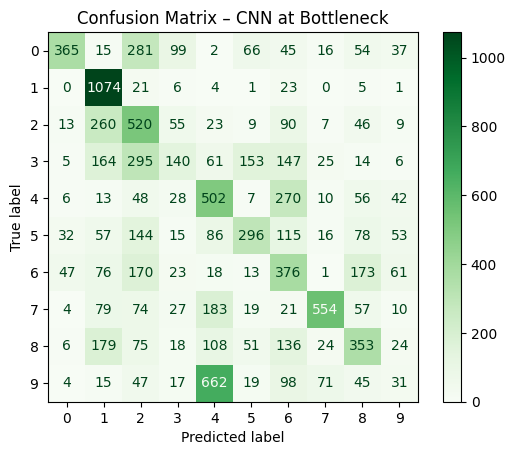

In [ ]:
clf_bn.eval()
with torch.no_grad():
    preds = clf_bn(X_test.to(device)).argmax(dim=1)

cm_bn = confusion_matrix(y_test, preds.cpu())
disp = ConfusionMatrixDisplay(cm_bn)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix – CNN at Bottleneck")
plt.savefig("reports/figures/cm_bottleneck.png")
plt.show()


In [ ]:
params_bn = sum(p.numel() for p in clf_bn.parameters() if p.requires_grad)
print("Classifier Parameters (At Bottleneck):", params_bn)


Classifier Parameters (At Bottleneck): 4810


In [ ]:
report = pd.DataFrame({
    "Pipeline": ["CNN on Noisy Images", "CNN at Bottleneck"],
    "Parameters": [params_noisy, params_bn]
})

report.to_csv("reports/model_comparison.csv", index=False)
report


,Pipeline,Parameters
0,CNN on Noisy Images,421642
1,CNN at Bottleneck,4810


# **The Accuracy of the all the three piplines and find the optimal size of the bottleneck for max accuracy**

In [ ]:
def compute_accuracy(model, loader, use_noise=False, is_bottleneck=False, autoencoder=None):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if use_noise:
                images = add_gaussian_noise(images)

            if is_bottleneck:
                encoded = autoencoder.encoder(images.view(images.size(0), -1))
                outputs = model(encoded)
            else:
                outputs = model(images)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


# **Accuracy of Pipeline 1 (Noisy CNN)**

In [ ]:
acc_noisy = compute_accuracy(cnn_noisy, test_loader, use_noise=True)
print(f"Accuracy – CNN on Noisy Images: {acc_noisy:.2f}%")


Accuracy – CNN on Noisy Images: 97.46%


# **Accuracy of Pipeline 3 (Clean Baseline CNN)**

In [ ]:
cnn_clean = CNNClassifier().to(device)
optimizer = optim.Adam(cnn_clean.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = cnn_clean(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

acc_clean = compute_accuracy(cnn_clean, test_loader)
print(f"Accuracy – CNN on Clean Images (Baseline): {acc_clean:.2f}%")


Accuracy – CNN on Clean Images (Baseline): 99.15%


# **Test Multiple Bottleneck Sizes**

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, bottleneck_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, bottleneck_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [ ]:
bottleneck_sizes = [128, 64, 32, 16]
results = []

for size in bottleneck_sizes:
    print(f"\nTesting Bottleneck Size: {size}")

    model = DenoisingAutoencoder(bottleneck_dim=size).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # Train Autoencoder (short training for experiment)
    for epoch in range(30):
        for images, _ in train_loader:
            images = images.to(device)
            noisy = add_gaussian_noise(images)
            images_flat = images.view(images.size(0), -1)
            noisy_flat = noisy.view(noisy.size(0), -1)

            outputs = model(noisy_flat)
            loss = criterion(outputs, images_flat)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Extract Bottleneck Features
    X_train, y_train = extract_bottleneck_features(model, train_loader)
    X_test, y_test = extract_bottleneck_features(model, test_loader)

    clf_bn = BottleneckClassifier(size).to(device)
    optimizer = optim.Adam(clf_bn.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(30):
        optimizer.zero_grad()
        outputs = clf_bn(X_train.to(device))
        loss = criterion(outputs, y_train.to(device))
        loss.backward()
        optimizer.step()

    acc_bn = (clf_bn(X_test.to(device)).argmax(dim=1) == y_test.to(device)).float().mean().item() * 100

    params_bn = sum(p.numel() for p in clf_bn.parameters() if p.requires_grad)

    results.append((size, acc_bn, params_bn))

    print(f"Accuracy: {acc_bn:.2f}%")
    print(f"Parameters: {params_bn}")



Testing Bottleneck Size: 128
Accuracy: 77.35%
Parameters: 8906

Testing Bottleneck Size: 64
Accuracy: 70.86%
Parameters: 4810

Testing Bottleneck Size: 32
Accuracy: 63.44%
Parameters: 2762

Testing Bottleneck Size: 16
Accuracy: 59.81%
Parameters: 1738


In [ ]:
import pandas as pd

df = pd.DataFrame(results, columns=["Bottleneck Size", "Accuracy (%)", "Parameters"])
df


,Bottleneck Size,Accuracy (%),Parameters
0,128,77.349997,8906
1,64,70.859998,4810
2,32,63.440001,2762
3,16,59.810001,1738


In [ ]:
best_row = df.loc[df["Accuracy (%)"].idxmax()]
print("\nBest Accuracy:")
print(best_row)



Best Accuracy:
Bottleneck Size     128.000000
Accuracy (%)         77.349997
Parameters         8906.000000
Name: 0, dtype: float64


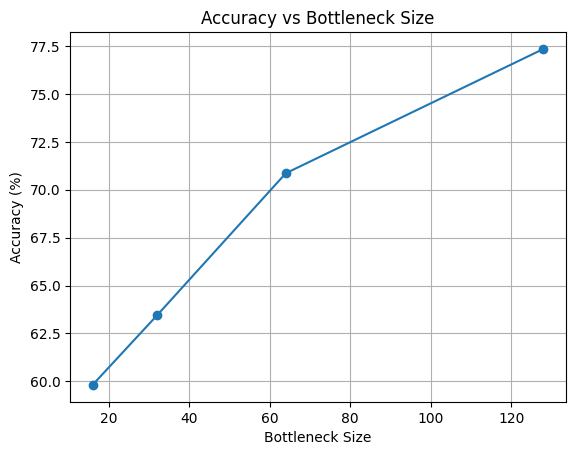

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df["Bottleneck Size"], df["Accuracy (%)"], marker='o')
plt.xlabel("Bottleneck Size")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Bottleneck Size")
plt.grid()
plt.show()
